# Model 2 - Random Forest
**Owner:** _(your name)_  |  **Branch:** `model/random-forest`  |  **Stage 6 + 7** - model development, comparison and optimisation

Bagging of many decorrelated decision trees. Robust and a strong tabular baseline, but it is the slowest model to train and tune here.

> **How to run:** first set `DATA_FRAC = 0.1` to check that everything works (a few minutes), then set it to `1.0` and *Run All* for the real results.
> Everything here uses the shared code in `src/` - same split, same 5 folds, same metrics as the other members.

## 1. Setup and data

In [1]:
import sys; sys.path.append("../src")
import warnings; warnings.filterwarnings("ignore")
from common import *
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

NAME = "Random Forest"

# ---- run configuration ---------------------------------------------------------------------------
DATA_FRAC        = 1.0    # share of TRAINING patients used in this notebook (0.1 = quick check run)
EXP_FRAC         = 0.3    # share of patients used for the small experiments in section 4
TUNE_SAMPLE_FRAC = 0.3    # share of patients used DURING the search (the best model is refitted on ALL data)
N_ITER           = 15     # candidates tried by random / halving search
SEARCH_METHOD    = "random"   # "random" | "grid" | "halving"
# --------------------------------------------------------------------------------------------------
reset_log(NAME)

In [2]:
X_train, X_test, y_train, y_test, g_train, cv, class_names = load_and_split()
X_train, y_train, g_train = patient_subsample(X_train, y_train, g_train, DATA_FRAC)
X_exp, y_exp, g_exp = patient_subsample(X_train, y_train, g_train, EXP_FRAC)
print("train", X_train.shape, "| test", X_test.shape, "| classes", class_names)
pd.Series(y_train).map(dict(enumerate(class_names))).value_counts(normalize=True).round(3)

train (79541, 50) | test (19802, 50) | classes ['<30', '>30', 'NO']


NO     0.528
>30    0.357
<30    0.114
Name: proportion, dtype: float64

## 2. Why this model? (algorithm selection and justification)

- **Task fit:** native multiclass with probability outputs (average of tree votes).
- **Data fit:** handles mixed features and non-linear interactions, needs no scaling, robust to noise and outliers. **Weaknesses:** slow and memory-hungry on ~2,400 sparse columns; impurity-based importance is biased towards high-cardinality features (the diagnosis codes).
- **Idea:** averaging many de-correlated deep trees (bootstrap samples + random feature subsets) cuts variance without raising bias much.

## 3. Baseline model and validation strategy
- **Validation:** 5-fold `StratifiedGroupKFold` on the training set, grouped by `patient_nbr` (a patient never appears in both the training and validation part of a fold) and stratified (the rare `<30` class, about 11%, appears in every fold). The folds are fixed (`random_state=42`) and identical for every model.
- **Preprocessing inside the pipeline:** imputation, scaling and one-hot encoding are refitted on the training part of each fold, so nothing leaks from the validation part.
- **Imbalance:** handled with class weights, not by resampling (SMOTE works poorly on ~2,400 sparse one-hot columns).
- **Main metric: macro-F1** (every class counts equally). Accuracy is misleading here because always predicting `NO` already scores about 55%. We also track macro-recall, ROC-AUC (one-vs-rest) and PR-AUC / recall for the `<30` class.
- The **test set is not touched** until section 6.

In [3]:
def make_pipe(**kw):
    params = dict(n_estimators=150, min_samples_leaf=5, class_weight="balanced_subsample",
                  n_jobs=-1, random_state=RANDOM_STATE)
    params.update(kw)
    return Pipeline([("pre", make_preprocessor(scale=False)),
                     ("m", RandomForestClassifier(**params))])


pipe = make_pipe()
baseline = cv_evaluate(pipe, X_train, y_train, g_train, cv)
pd.Series({k: round(v, 4) for k, v in baseline.items() if not isinstance(v, list)})

cv_macro_f1            0.4437
cv_weighted_f1         0.5251
cv_macro_recall        0.4555
cv_macro_precision     0.4446
cv_accuracy            0.5232
cv_roc_auc_ovr         0.6638
cv_pr_auc_lt30         0.2061
cv_recall_lt30         0.3302
cv_precision_lt30      0.2156
cv_f1_lt30             0.2608
cv_macro_f1_std        0.0088
cv_pr_auc_lt30_std     0.0055
train_macro_f1         0.5876
fit_time_s            11.1394
dtype: float64

### Baseline observations
_Write 2-3 sentences: How does the baseline compare with the majority-class score (macro-F1 about 0.23)? Is there a big gap between `train_macro_f1` and `cv_macro_f1` (over-fitting)?_

## 4. Experiments - understanding why the model behaves the way it does
Each experiment is cross-validated with the same folds on a patient sample (`EXP_FRAC`) and is saved automatically to `outputs/results/<model>_experiments.csv` (this is your experiment record for the report).

### Experiment 1
**Tree depth** - deeper trees fit more detail but can over-fit.

[max_depth] max_depth=4: macro-F1=0.3900 (train 0.4117)
[max_depth] max_depth=8: macro-F1=0.4069 (train 0.4517)
[max_depth] max_depth=12: macro-F1=0.4194 (train 0.4931)
[max_depth] max_depth=16: macro-F1=0.4295 (train 0.5282)
[max_depth] max_depth=24: macro-F1=0.4334 (train 0.5819)


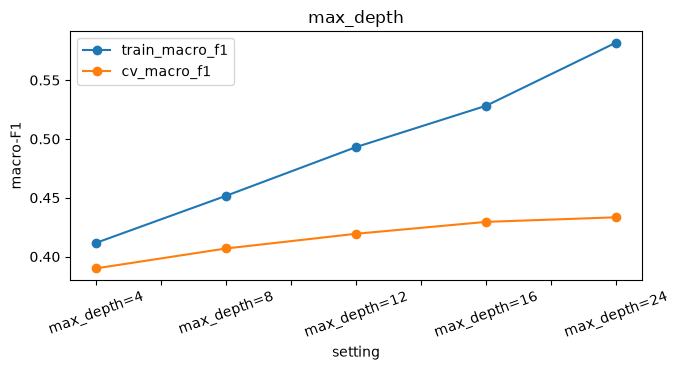

,experiment,setting,cv_macro_f1,train_macro_f1,cv_macro_recall,cv_roc_auc_ovr,cv_pr_auc_lt30,fit_time_s
0,max_depth,max_depth=4,0.3900,0.4117,0.4394,0.6478,0.1751,0.6368
1,max_depth,max_depth=8,0.4069,0.4517,0.4438,0.6536,0.1866,0.5910
2,max_depth,max_depth=12,0.4194,0.4931,0.4442,0.6540,0.1925,0.6623
3,max_depth,max_depth=16,0.4295,0.5282,0.4470,0.6560,0.1894,0.6860
4,max_depth,max_depth=24,0.4334,0.5819,0.4422,0.6564,0.1931,0.8328


In [4]:
sweep(NAME, "max_depth", [4, 8, 12, 16, 24], lambda v: make_pipe(max_depth=v, n_estimators=80), X_exp, y_exp, g_exp, cv)

**Observation:** _(what did you see and why? one or two sentences)_

### Experiment 2
**Number of trees** - more trees reduce variance until the score plateaus.

[n_estimators] n_estimators=25: macro-F1=0.4236 (train 0.5148)
[n_estimators] n_estimators=50: macro-F1=0.4286 (train 0.5240)
[n_estimators] n_estimators=100: macro-F1=0.4301 (train 0.5303)
[n_estimators] n_estimators=200: macro-F1=0.4294 (train 0.5323)


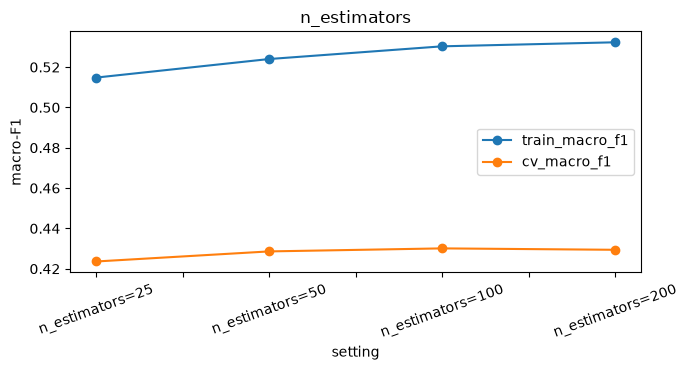

,experiment,setting,cv_macro_f1,train_macro_f1,cv_macro_recall,cv_roc_auc_ovr,cv_pr_auc_lt30,fit_time_s
0,n_estimators,n_estimators=25,0.4236,0.5148,0.4410,0.6472,0.1770,0.4086
1,n_estimators,n_estimators=50,0.4286,0.5240,0.4461,0.6533,0.1839,0.5249
2,n_estimators,n_estimators=100,0.4301,0.5303,0.4470,0.6568,0.1908,0.8168
3,n_estimators,n_estimators=200,0.4294,0.5323,0.4460,0.6575,0.1924,1.3408


In [5]:
sweep(NAME, "n_estimators", [25, 50, 100, 200], lambda v: make_pipe(n_estimators=v, max_depth=16), X_exp, y_exp, g_exp, cv)

**Observation:** _(what did you see and why? one or two sentences)_

### Experiment 3
**Features tried per split (`max_features`)** - lower values decorrelate the trees (more diversity) but weaken each tree.

[max_features] max_features=sqrt: macro-F1=0.4295 (train 0.5282)
[max_features] max_features=0.05: macro-F1=0.4354 (train 0.6111)
[max_features] max_features=0.2: macro-F1=0.4343 (train 0.7583)


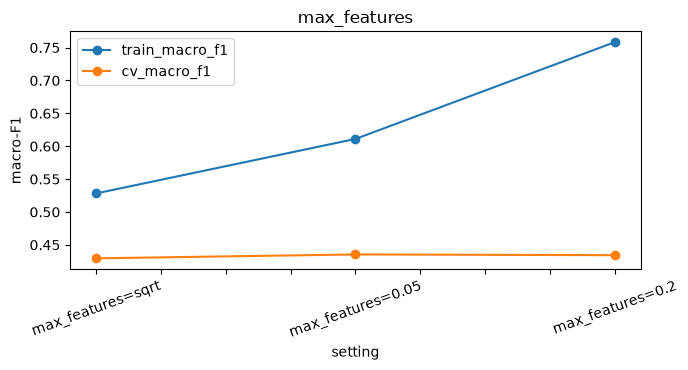

,experiment,setting,cv_macro_f1,train_macro_f1,cv_macro_recall,cv_roc_auc_ovr,cv_pr_auc_lt30,fit_time_s
0,max_features,max_features=sqrt,0.4295,0.5282,0.4470,0.6560,0.1894,0.6860
1,max_features,max_features=0.05,0.4354,0.6111,0.4397,0.6553,0.1933,1.1924
2,max_features,max_features=0.2,0.4343,0.7583,0.4329,0.6523,0.1891,5.1377


In [6]:
sweep(NAME, "max_features", ["sqrt", 0.05, 0.2], lambda v: make_pipe(max_features=v, max_depth=16, n_estimators=80), X_exp, y_exp, g_exp, cv)

**Observation:** _(what did you see and why? one or two sentences)_

### Experiment 4
**Feature selection: are the diagnosis codes worth their ~2,000 one-hot columns?** Compare with and without `diag_1`, `diag_2`, `diag_3`.

In [7]:
DIAG = ["diag_1", "diag_2", "diag_3"]
run_experiment(NAME, "Diagnosis ablation", "with diag_1-3", make_pipe(max_depth=16, n_estimators=80), X_exp, y_exp, g_exp, cv)
run_experiment(NAME, "Diagnosis ablation", "without diag_1-3", make_pipe(max_depth=16, n_estimators=80),
               X_exp.drop(columns=DIAG), y_exp, g_exp, cv)
show_experiments(NAME, "Diagnosis ablation")

[Diagnosis ablation] with diag_1-3: macro-F1=0.4295 (train 0.5282)
[Diagnosis ablation] without diag_1-3: macro-F1=0.4363 (train 0.6895)


,experiment,setting,cv_macro_f1,train_macro_f1,cv_macro_recall,cv_roc_auc_ovr,cv_pr_auc_lt30,fit_time_s
0,Diagnosis ablation,with diag_1-3,0.4295,0.5282,0.4470,0.6560,0.1894,0.6983
1,Diagnosis ablation,without diag_1-3,0.4363,0.6895,0.4363,0.6528,0.1832,1.5139


**Observation:** _(what did you see and why? one or two sentences)_

## 5. Hyper-parameter tuning (Stage 7)
**Search strategy:** **Random search** (`RandomizedSearchCV`, `N_ITER` candidates). The space is large (depth x leaf size x features per split x trees) and random search finds near-best settings with far fewer fits than a grid. If it is still too slow set `SEARCH_METHOD = "halving"` (successive halving: many candidates on little data, only the best on more data).

Scoring is **macro-F1** with the same grouped folds. To keep the search fast, it runs on `TUNE_SAMPLE_FRAC` of the patients and the best configuration is then **refitted on all training data**. The tuned model is re-evaluated with the full 5-fold CV so that baseline and tuned scores are directly comparable.

In [8]:
# max_depth is capped (no None) so the saved model stays small enough for the backend / GitHub
space = {"m__max_depth": [8, 12, 16, 24],
         "m__min_samples_leaf": [2, 5, 10, 20],
         "m__max_features": ["sqrt", 0.05, 0.2],
         "m__n_estimators": [100, 200, 300]}


tune_res = tune(pipe, space, X_train, y_train, g_train, cv,
                method=SEARCH_METHOD, n_iter=N_ITER, sample_frac=TUNE_SAMPLE_FRAC)
print("Best parameters:", tune_res.best_params_)
print(f"Search took {tune_res.search_time_s/60:.1f} min")
top_configs(tune_res)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters: {'m__n_estimators': 300, 'm__min_samples_leaf': 5, 'm__max_features': 0.2, 'm__max_depth': 12}
Search took 29.5 min


,param_m__n_estimators,param_m__min_samples_leaf,param_m__max_features,param_m__max_depth,mean_test_score,std_test_score
7,300,5,0.2,12,0.4412,0.0067
14,200,5,0.2,16,0.4376,0.0058
8,100,10,0.2,12,0.4365,0.0084
3,200,2,0.2,16,0.4321,0.0016
10,100,5,0.05,12,0.4318,0.0068


In [9]:
tuned = cv_evaluate(tune_res.best_estimator_, X_train, y_train, g_train, cv)   # full 5-fold CV, comparable with baseline
compare_table(baseline, tuned)

,baseline,tuned,change
CV macro-F1 (main metric),0.4437,0.4425,-0.0011
CV macro-recall,0.4555,0.4571,0.0016
CV accuracy,0.5232,0.5197,-0.0034
"CV ROC-AUC (OvR, macro)",0.6638,0.6599,-0.0039
CV PR-AUC for <30,0.2061,0.2151,0.0091
CV recall for <30,0.3302,0.3499,0.0197
Train macro-F1 (over-fit check),0.5876,0.5550,-0.0326
Fit time per fold (s),11.1394,61.1819,50.0425


**Observation:** _Did tuning help? By how much compared with the fold-to-fold spread (`cv_macro_f1_std`)? Which parameter mattered most?_

## 6. Final evaluation on the untouched test set (reported once)
The final model of the project is chosen later, in `compare_models.ipynb`, by **CV score - not by test score**.

              precision    recall  f1-score   support

         <30      0.210     0.361     0.265      2216
         >30      0.482     0.347     0.403      7090
          NO      0.646     0.669     0.657     10496

    accuracy                          0.519     19802
   macro avg      0.446     0.459     0.442     19802
weighted avg      0.538     0.519     0.522     19802



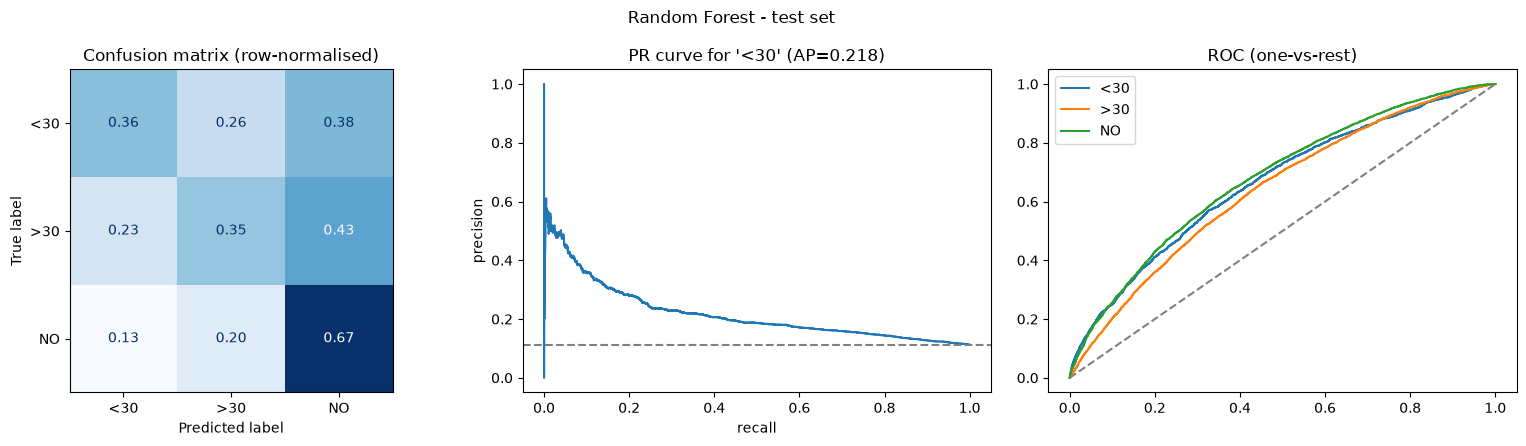

Saved outputs/results/random_forest.json and outputs/models/random_forest.joblib


In [10]:
result = finalize(NAME, baseline, tuned, tune_res, X_test, y_test, class_names)

## 7. Interpretation

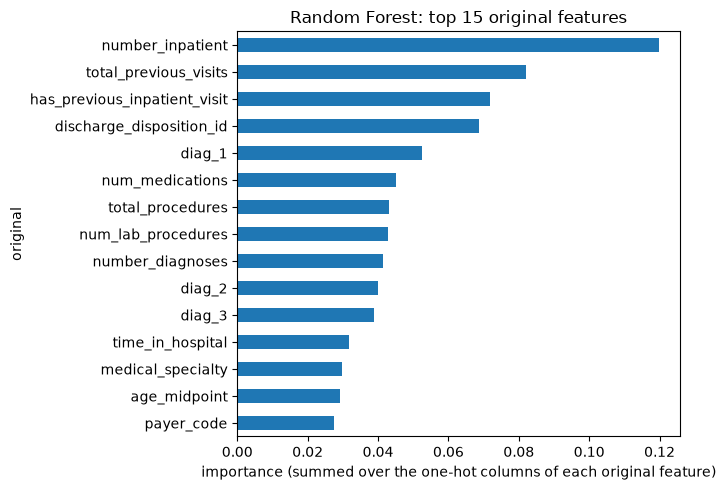

original
number_inpatient                0.1198
total_previous_visits           0.0822
has_previous_inpatient_visit    0.0717
discharge_disposition_id        0.0688
diag_1                          0.0525
num_medications                 0.0452
total_procedures                0.0430
num_lab_procedures              0.0429
number_diagnoses                0.0413
diag_2                          0.0398
diag_3                          0.0389
time_in_hospital                0.0317
medical_specialty               0.0298
age_midpoint                    0.0290
payer_code                      0.0274
Name: value, dtype: float64

In [11]:
best = tune_res.best_estimator_
tbl = feature_importance_table(best, X_train.columns)
top = top_original_features(tbl, 15)
plot_top_features(top, f"{NAME}: top 15 original features", NAME)
top.round(4)